# ENGR 1330 – Computational Thinking and Data Science

## Traffic volume Predictor Final Project - Background

Traffic congestion is a rising concern globally, escpecially for big cities. There can be numerous factors playing role determining traffic volume, and they are worth researching to understand and predict the traffic pattern at specific locations. Among different factors, time is a critical determinant of traffic congestion. Everywhere, there are particualr times in a day when number of vehicles passing through a crossroad is far higher than other times.   

Here we have a dataset that records traffic volume every hours at 3 different junctions in a city, for a period of 1 year and 8 months. You will find a way to predict the traffic at any time of the day at any junction.  

## Objective(s):
- Literature scan on traffic flow analysis, and necessity of investigating temporal pattern of traffic flow
- Analyse an existing traffic volume database and build a data model to predict the traffic 
- Build an interface to allow users to enter date and time and return an estimated traffic volume and an assessment of the uncertainty in the estimate
- Build an interface to allow users to add observations to the underlying database, and automatically update the Data Model to incorporate the new observations

## Tasks: 

**Literature Research:**

Do some background study on temporal traffic behavior and its significance. Here are some good ones to begin with:
1. https://onlinelibrary.wiley.com/doi/epdf/10.1111/0885-9507.00200
2. https://proceedings.esri.com/library/userconf/proc08/papers/papers/pap_1613.pdf
3. https://www.sciencedirect.com/science/article/pii/S1352231015001661?casa_token=89oxxn8VJ2gAAAAA:QMwqati_EyuC_BbzS8IRDOJ1kSev-kcHcUk5NTVwfH4RP4G397ZI-IhfkMK6sYJF2jm9YTI0QA



**Exploratory Data Analysis**
- Describe the data. Include statistical and visual description of the data.
- Create pairplots for all the appropriate columns and check for correlation coefficients, make comments on your observation 

**Model Building**
- For each of the 3 junctions, you should come up with a model to predict the traffic volume at any time of  a day. To find a best model, test at least 2 different models for each junction, and compare accuracy. For each junction:
     - you should  determine which input strongly affects the traffic flow. 
     - Build 2 models using the input factor for each junction. You can adopt any 2 different mathematical model (e.g. linear, polynomial etc)
     - Assess data model quality (decide which model is best) including appropriate metric
- Build the input data interface for using the model
- Using the model for each zone, determine projected traffic volume for each junction, and an assessment of uncertainty for the following times of a day: 2 am, 6 am, 3 pm and 7 pm. 
               
       
**Documentation**
- Training and Project management video on how to use your tool, and demonstrate the tool(s) as they are run
- Interim report (see deliverables below); this document must be rendered as a .pdf, Word template is in BlackBoard.
- Final ipynb file (see deliverables below)

## Deliverables:

#### Part 1 Interim Report (due Dec 3):
A report that briefly describes the project. Use the Interim Report Template in Canvas. 
- Break down each task into manageable subtasks and describe how you intend to solve the subtasks and how you will test each task. (Perhaps list of meeting times). 
- Address the responsibilities of each team member for tasks completed and tasks to be completed until the end of the semester. (Perhaps make explicit subtask assignments). If you would work all together just state it in the report. 

#### Part 2 Final Report (due Dec 10):
- A well-documented JupyterLab (using a python kernel), use markdown cells and commenting for explanations and text.
- Html version of the ipynb file.
- A how-to video demonstrating performance and description of problems that you were not able to solve and also talk about project management such as who did what. You can choose a speaker to narrate.
- A final peer evaluation report, where each group member should rate the participation and contribution of the other members.

**Above items can reside in a single video; but structure the video into the two parts; use an obvious transition when moving from "how to ..." into the project management portion.**  Keep the total video length to less than 10 minutes; submit as an *unlisted* YouTube video, and just supply the link (someone on each team is likely to have a YouTube creator account).  Keep in mind a 10 minute video can approach 100MB file size before compression, so it won't upload to Canvas and cannot be emailed.



# <font color=red>OUR PROJECT STARTS FROM HERE</font>

### Traffic Data Headers Explanation

*   **`Vehicles`**: The target variable (dependent variable). The number of vehicles passing through the junction during that specific hour.
*   **`Hour`**: The hour of the day (0 to 23). A key temporal feature for capturing daily traffic patterns.
*   **`Date`**: The day of the month (1 to 31). Useful for capturing weekday vs. weekend patterns.
*   **`Month`**: The month of the year (1 to 12). Useful for capturing seasonal changes.
*   **`Year`**: The year the data was recorded (e.g., 2015). Useful for observing macro-trends over time.
*   **`Junction`**: A categorical identifier (1, 2, or 3) representing the specific crossroad location. Models should be built separately for each junction.
*   **`ID`**: A unique numerical identifier for each row, constructed by concatenating Year, Month, Date, Hour, and Junction.

### Exploratory Data Analysis
First, let's load the data and examine its basic structure and statistics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('Traffic data.csv')
df.head()

,ID,Year,Month,Hour,Date,Junction,Vehicles
0,20151101001,2015,11,0,1,1,15
1,20151101011,2015,11,1,1,1,13
2,20151101021,2015,11,2,1,1,10
3,20151101031,2015,11,3,1,1,7
4,20151101041,2015,11,4,1,1,9


#### Statistical Description

In [2]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ID        43776 non-null  int64
 1   Year      43776 non-null  int64
 2   Month     43776 non-null  int64
 3   Hour      43776 non-null  int64
 4   Date      43776 non-null  int64
 5   Junction  43776 non-null  int64
 6   Vehicles  43776 non-null  int64
dtypes: int64(7)
memory usage: 2.3 MB


In [3]:
# Summary statistics
df.describe()

,ID,Year,Month,Hour,Date,Junction,Vehicles
count,4.377600e+04,43776.000000,43776.000000,43776.000000,43776.000000,43776.000000,43776.000000
mean,2.016260e+10,2016.197368,6.120066,11.500000,15.710526,2.000000,24.333379
std,5.779462e+06,0.599233,3.619760,6.922266,8.788835,0.816506,21.112090
min,2.015110e+10,2015.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,2.016038e+10,2016.000000,3.000000,5.750000,8.000000,1.000000,10.000000
50%,2.016083e+10,2016.000000,6.000000,11.500000,16.000000,2.000000,17.000000
75%,2.017013e+10,2017.000000,10.000000,17.250000,23.000000,3.000000,32.000000
max,2.017063e+10,2017.000000,12.000000,23.000000,31.000000,3.000000,180.000000


**Observations:**
- The dataset contains no missing values, saving us from imputation steps.
- The data spans across multiple junctions and includes temporal features (Year, Month, Date, Hour).
- The `ID` column is an identifier composed of the date/time/junction, and won't be useful for correlation.

#### Visual Description

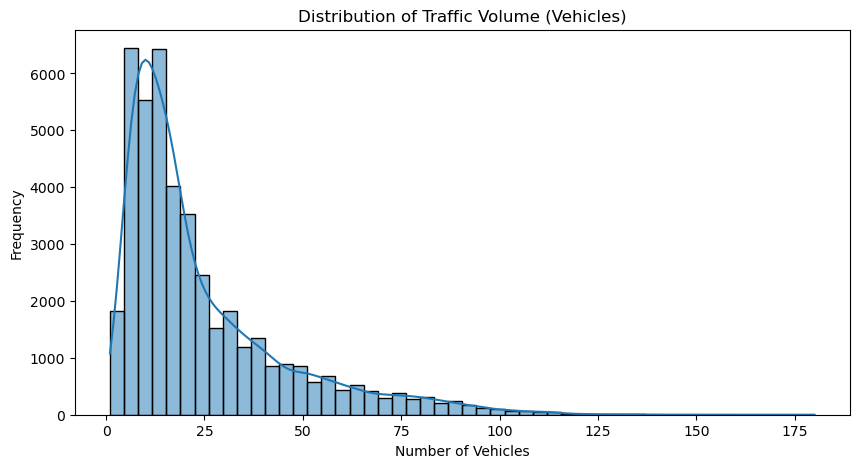

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Vehicles'], bins=50, kde=True)
plt.title('Distribution of Traffic Volume (Vehicles)')
plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency')
plt.show()

#### Pairplots and Correlation Analysis
We will drop the `ID` column to focus on the meaningful numerical and categorical features.

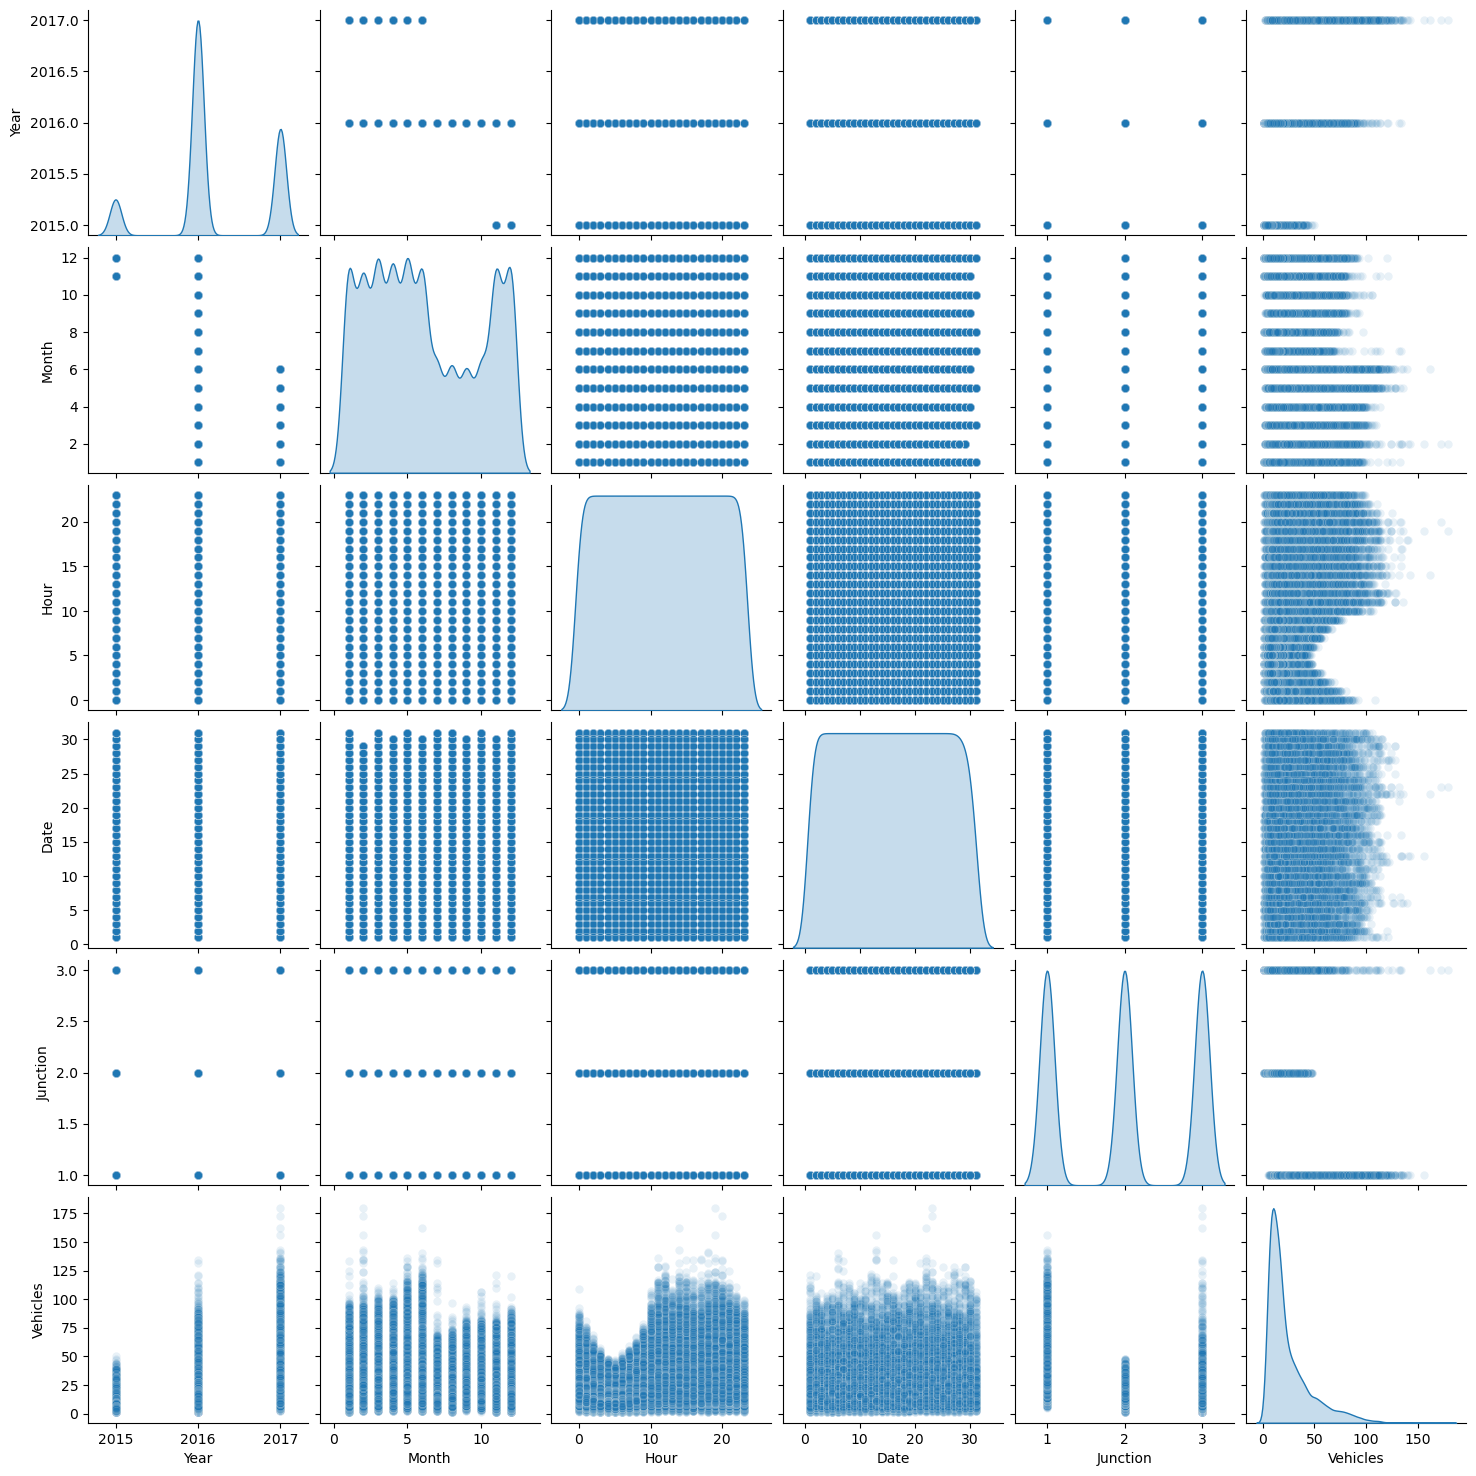

In [5]:
# Drop ID for the pairplot and correlation analysis
df_features = df.drop(columns=['ID'])

# Create a pairplot
sns.pairplot(df_features, diag_kind='kde', plot_kws={'alpha': 0.1})
plt.show()

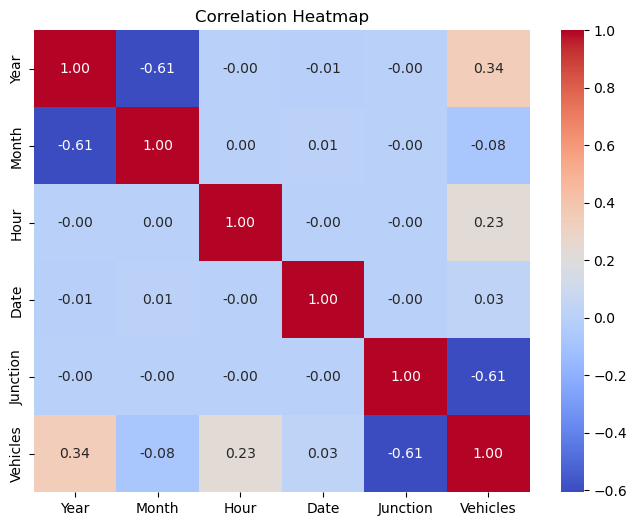

In [6]:
# Calculate correlation coefficients
corr_matrix = df_features.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Correlation Observations:**
- **`Hour` vs `Vehicles`**: The correlation coefficient between Hour and Vehicles is positive, but correlation only measures *linear* relationships. We know traffic is cyclical (peaks at rush hour, drops at night), so the linear correlation doesn't capture the whole story.
- **`Junction` vs `Vehicles`**: There's a negative correlation between Junction ID and Vehicles. This likely indicates that the junctions with higher IDs (e.g., Junction 3 or 4) generally have lower traffic volumes compared to Junction 1.
- **`Year`/`Month` vs `Vehicles`**: Small correlations exist, possibly indicating slight overall growth in traffic year-over-year, or seasonal changes by month.

### Model Building
Based on the exploratory data analysis, **Hour** strongly affects traffic flow and displays cyclical behavior. We will use `Hour` as our primary input to predict `Vehicles`.

We will test two models for each junction:
1. **Linear Regression**
2. **Polynomial Regression (Degree 4)**


--- Evaluating Models for Junction 1 ---
Linear Regression Formula - y = 1.25x + 30.64
Linear Regression - RMSE: 21.31, R-squared: 0.14
Polynomial Regression (D=4) - RMSE: 20.17, R-squared: 0.23
-> Selected Model: Polynomial Regression


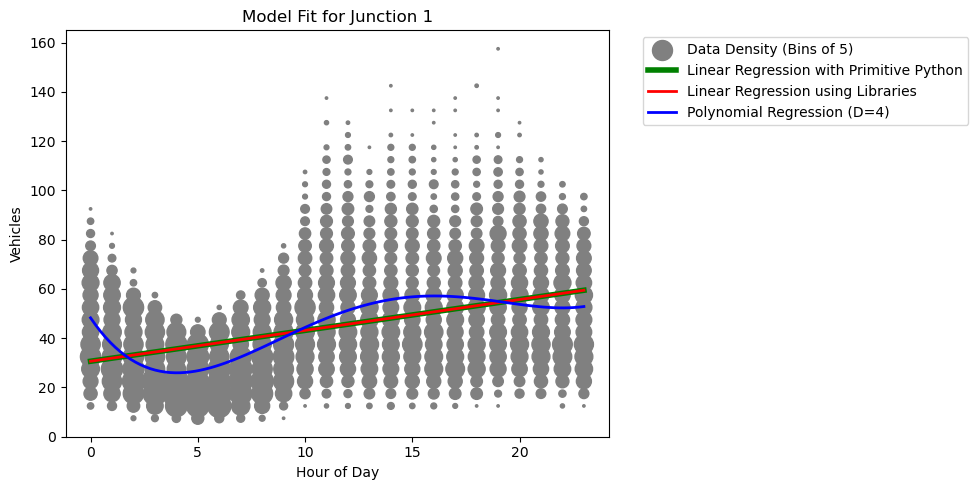


--- Evaluating Models for Junction 2 ---
Linear Regression Formula - y = 0.30x + 10.82
Linear Regression - RMSE: 7.11, R-squared: 0.08
Polynomial Regression (D=4) - RMSE: 6.86, R-squared: 0.14
-> Selected Model: Polynomial Regression


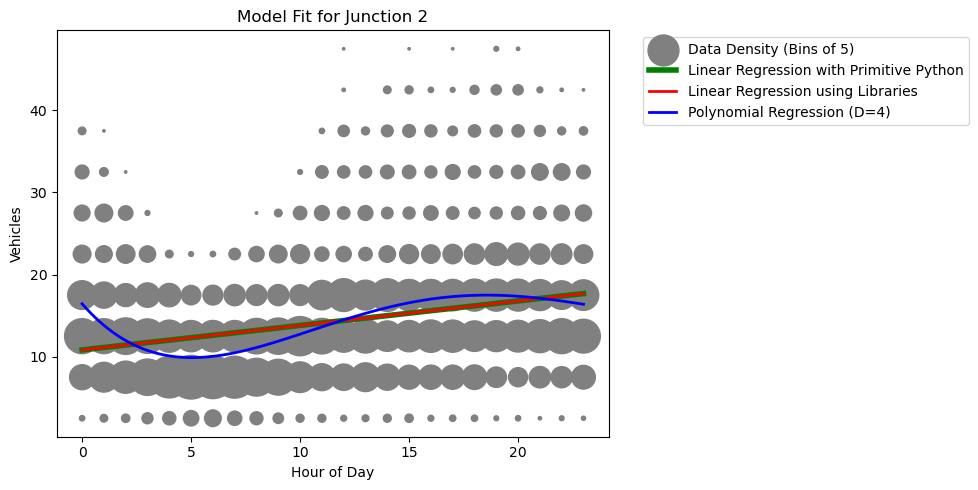


--- Evaluating Models for Junction 3 ---
Linear Regression Formula - y = 0.56x + 7.31
Linear Regression - RMSE: 9.70, R-squared: 0.14
Polynomial Regression (D=4) - RMSE: 9.34, R-squared: 0.20
-> Selected Model: Polynomial Regression


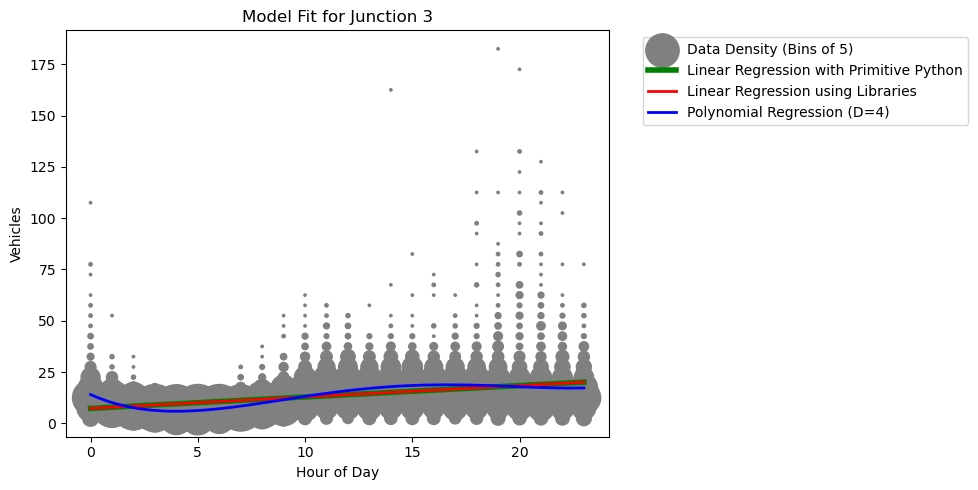

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Prepare a dictionary to store our models, their metrics, and the best model for each junction
junction_models = {}

for junction in [1, 2, 3]:
    print(f"\n--- Evaluating Models for Junction {junction} ---")
    
    # Filter data for the specific junction
    j_data = df[df['Junction'] == junction]
    X = j_data[['Hour']].values
    y = j_data['Vehicles'].values
    
    # 1.1 Linear Regression with primitive python 
    X_mean = X.mean()
    y_mean = y.mean()

    covariance = ((j_data['Hour'] - X_mean) * (j_data['Vehicles'] - y_mean)).sum()
    X_variance = ((j_data['Hour'] - X_mean)**2).sum()

    beta = covariance / X_variance
    alpha = y_mean - (beta * X_mean)

    print(f'Linear Regression Formula - y = {beta:.2f}x + {alpha:.2f}')

    prim_lin_reg = lambda x: (beta*x) + alpha
    
    # 1.2 Linear Regression using libraries
    lin_reg = LinearRegression()
    lin_reg.fit(X, y)
    y_pred_lin = lin_reg.predict(X)
    rmse_lin = np.sqrt(mean_squared_error(y, y_pred_lin))
    r2_lin = r2_score(y, y_pred_lin)
    print(f"Linear Regression - RMSE: {rmse_lin:.2f}, R-squared: {r2_lin:.2f}")
    
    # 2. Polynomial Regression (Degree 4)
    poly_features = PolynomialFeatures(degree=4)
    X_poly = poly_features.fit_transform(X)
    poly_reg = LinearRegression()
    poly_reg.fit(X_poly, y)
    y_pred_poly = poly_reg.predict(X_poly)
    rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
    r2_poly = r2_score(y, y_pred_poly)
    print(f"Polynomial Regression (D=4) - RMSE: {rmse_poly:.2f}, R-squared: {r2_poly:.2f}")
    
    # Assess Data Model Quality (Select Best)
    if rmse_poly < rmse_lin:
        print("-> Selected Model: Polynomial Regression")
        best_model = poly_reg
        best_rmse = rmse_poly
        is_poly = True
    else:
        print("-> Selected Model: Linear Regression")
        best_model = lin_reg
        best_rmse = rmse_lin
        is_poly = False
        
    # Save the best model for this junction
    junction_models[junction] = {
        'model': best_model,
        'rmse': best_rmse,
        'is_poly': is_poly,
        'poly_transformer': poly_features if is_poly else None
    }
    
    # --- Visualization ---
    plt.figure(figsize=(10, 5))
    
    # Bin the data into intervals of 5 vehicles for each hour
    plot_df = pd.DataFrame({'Hour': X.flatten(), 'Vehicles': y})
    # Create bins of 5 (e.g. 0-4 -> 2.5, 5-9 -> 7.5)
    plot_df['Vehicle_Bin'] = (plot_df['Vehicles'] // 5) * 5 + 2.5
    grouped = plot_df.groupby(['Hour', 'Vehicle_Bin']).size().reset_index(name='Count')
    
    # Plot as a bubble chart where circle size corresponds to the number of data points
    plt.scatter(grouped['Hour'], grouped['Vehicle_Bin'], s=grouped['Count']*3, color='gray', label='Data Density (Bins of 5)')
    
    # Generate points for smooth line
    X_plot = np.linspace(0, 23, 100).reshape(-1, 1)
    
    # Linear Regression line with Primitive Python
    y_plot_prim_lin = prim_lin_reg(X_plot)
    plt.plot(X_plot, y_plot_prim_lin, color='green', label='Linear Regression with Primitive Python', linewidth=4)
    
    # Linear Regression line using Libraries
    y_plot_lin = lin_reg.predict(X_plot)
    plt.plot(X_plot, y_plot_lin, color='red', label='Linear Regression using Libraries', linewidth=2)
    
    # Polynomial Regression curve
    X_plot_poly = poly_features.transform(X_plot)
    y_plot_poly = poly_reg.predict(X_plot_poly)
    plt.plot(X_plot, y_plot_poly, color='blue', label='Polynomial Regression (D=4)', linewidth=2)
    
    plt.title(f'Model Fit for Junction {junction}')
    plt.xlabel('Hour of Day')
    plt.ylabel('Vehicles')
    # Move legend outside the plot so it doesn't overlap the bubbles
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [6]:
# Data Summary using Statsmodels Library

import statsmodels.formula.api as smf

for junction in [1, 2, 3]:
    print(f"\n\t\t\t--- Summary for Junction {junction} ---")
    currentJunction = df[df['Junction'] == junction]

    # Initializing and Fitting the linear regression model so we can get the summary
    junctionModel = smf.ols('Vehicles ~ Hour', data=currentJunction)
    junctionModel = junctionModel.fit()

    # Print the model summary
    print(junctionModel.summary())


			--- Summary for Junction 1 ---
                            OLS Regression Results                            
Dep. Variable:               Vehicles   R-squared:                       0.142
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     2417.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:12:08   Log-Likelihood:                -65345.
No. Observations:               14592   AIC:                         1.307e+05
Df Residuals:                   14590   BIC:                         1.307e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.

#### Understanding Our Evaluation Metrics

To decide which model is the "best", we used two standard mathematical metrics:

1. **RMSE (Root Mean Squared Error):** This measures the average distance between the model's predictions and the actual traffic volume. The unit of RMSE is exactly the same as our target variable. For example, an RMSE of 5.2 means our model's predictions are, on average, off by about 5.2 vehicles. **Lower is better.**
2. **R-squared ($R^2$):** This represents the proportion of the variance in the traffic volume that is predictable from the hour of the day. An $R^2$ of 1.0 means perfect prediction, while 0.0 means the model performs no better than simply guessing the overall average traffic volume every time. **Higher is better.**

#### Input Data Interface
Using `ipywidgets` to create an interactive interface to query the model. Select a junction and hour to see the predicted traffic volume and uncertainty.

In [7]:
import ipywidgets as widgets
import warnings
warnings.filterwarnings('ignore')

@widgets.interact(
    junction=widgets.Dropdown(options=[1, 2, 3], value=1, description='Junction:'),
    hour=widgets.IntSlider(value=12, min=0, max=23, step=1, description='Hour (0-23):', continuous_update=False)
)
def predict_traffic(junction=1, hour=12):
    model_info = junction_models[junction]
    model = model_info['model']
    is_poly = model_info['is_poly']
    rmse = model_info['rmse']
    
    X_input = np.array([[hour]])
    if is_poly:
        X_input = model_info['poly_transformer'].transform(X_input)
        
    prediction = model.predict(X_input)[0]
    prediction = max(0, int(round(prediction)))
    
    print(f"Predicted Traffic Volume: {prediction} vehicles")
    print(f"Uncertainty (±RMSE): ±{rmse:.2f} vehicles")
    print(f"Expected Range: {max(0, int(prediction - rmse))} to {int(prediction + rmse)} vehicles")

interactive(children=(Dropdown(description='Junction:', options=(1, 2, 3), value=1), IntSlider(value=12, conti…

#### Predictions for Specific Times
Projected traffic volume and uncertainty assessment for 2 AM, 6 AM, 3 PM (15:00), and 7 PM (19:00).

In [9]:
target_hours = {'2 AM': 2, '6 AM': 6, '3 PM': 15, '7 PM': 19}

for junction in [1, 2, 3]:
    print(f"\n=== Projected Traffic for Junction {junction} ===")
    model_info = junction_models[junction]
    model = model_info['model']
    is_poly = model_info['is_poly']
    rmse = model_info['rmse']
    
    for time_label, hour in target_hours.items():
        X_input = np.array([[hour]])
        if is_poly:
            X_input = model_info['poly_transformer'].transform(X_input)
            
        pred = model.predict(X_input)[0]
        pred = max(0, int(round(pred)))
        print(f"{time_label} (Hour {hour}): ~{pred} vehicles (Uncertainty: ±{rmse:.2f})")



=== Projected Traffic for Junction 1 ===
2 AM (Hour 2): ~31 vehicles (Uncertainty: ±20.17)
6 AM (Hour 6): ~29 vehicles (Uncertainty: ±20.17)
3 PM (Hour 15): ~57 vehicles (Uncertainty: ±20.17)
7 PM (Hour 19): ~55 vehicles (Uncertainty: ±20.17)

=== Projected Traffic for Junction 2 ===
2 AM (Hour 2): ~12 vehicles (Uncertainty: ±6.86)
6 AM (Hour 6): ~10 vehicles (Uncertainty: ±6.86)
3 PM (Hour 15): ~17 vehicles (Uncertainty: ±6.86)
7 PM (Hour 19): ~17 vehicles (Uncertainty: ±6.86)

=== Projected Traffic for Junction 3 ===
2 AM (Hour 2): ~8 vehicles (Uncertainty: ±9.34)
6 AM (Hour 6): ~7 vehicles (Uncertainty: ±9.34)
3 PM (Hour 15): ~18 vehicles (Uncertainty: ±9.34)
7 PM (Hour 19): ~18 vehicles (Uncertainty: ±9.34)
